In [1]:
from IPython import get_ipython
get_ipython().run_line_magic("matplotlib", "inline") 
import matplotlib.pyplot as plt
import matplotlib
print(matplotlib.get_backend())  

inline


<xarray.Dataset> Size: 9MB
Dimensions:    (time: 552, lat: 51, lon: 41)
Coordinates:
  * time       (time) datetime64[ns] 4kB 1980-01-01T00:30:00 ... 2025-12-01T0...
  * lat        (lat) float64 408B 25.0 25.5 26.0 26.5 ... 48.5 49.0 49.5 50.0
  * lon        (lon) float64 328B -90.0 -89.38 -88.75 ... -66.25 -65.62 -65.0
Data variables:
    TOA_LW_UP  (time, lat, lon) float32 5MB ...
    TOA_SW_UP  (time, lat, lon) float32 5MB ...
Attributes:
    title:             MERRA-2 Eastern US TOA upwelling longwave and shortwav...
    source_directory:  /scratch/sjacker2/project_data/merra2_rad_downloads
    note:              TOA_LW_UP = LWTUP; TOA_SW_UP = SWTDN - SWTNT. Data alr...
<xarray.Dataset> Size: 13kB
Dimensions:    (time: 552)
Coordinates:
  * time       (time) datetime64[ns] 4kB 1980-01-01T00:30:00 ... 2025-12-01T0...
Data variables:
    PM25_mean  (time) float64 4kB ...
    T2M_mean   (time) float64 4kB ...
Attributes:
    title:         Monthly eastern US means of dry MERRA-2 PM2.5

/tmp/ipykernel_940990/2621739267.py:137: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  ax.legend(


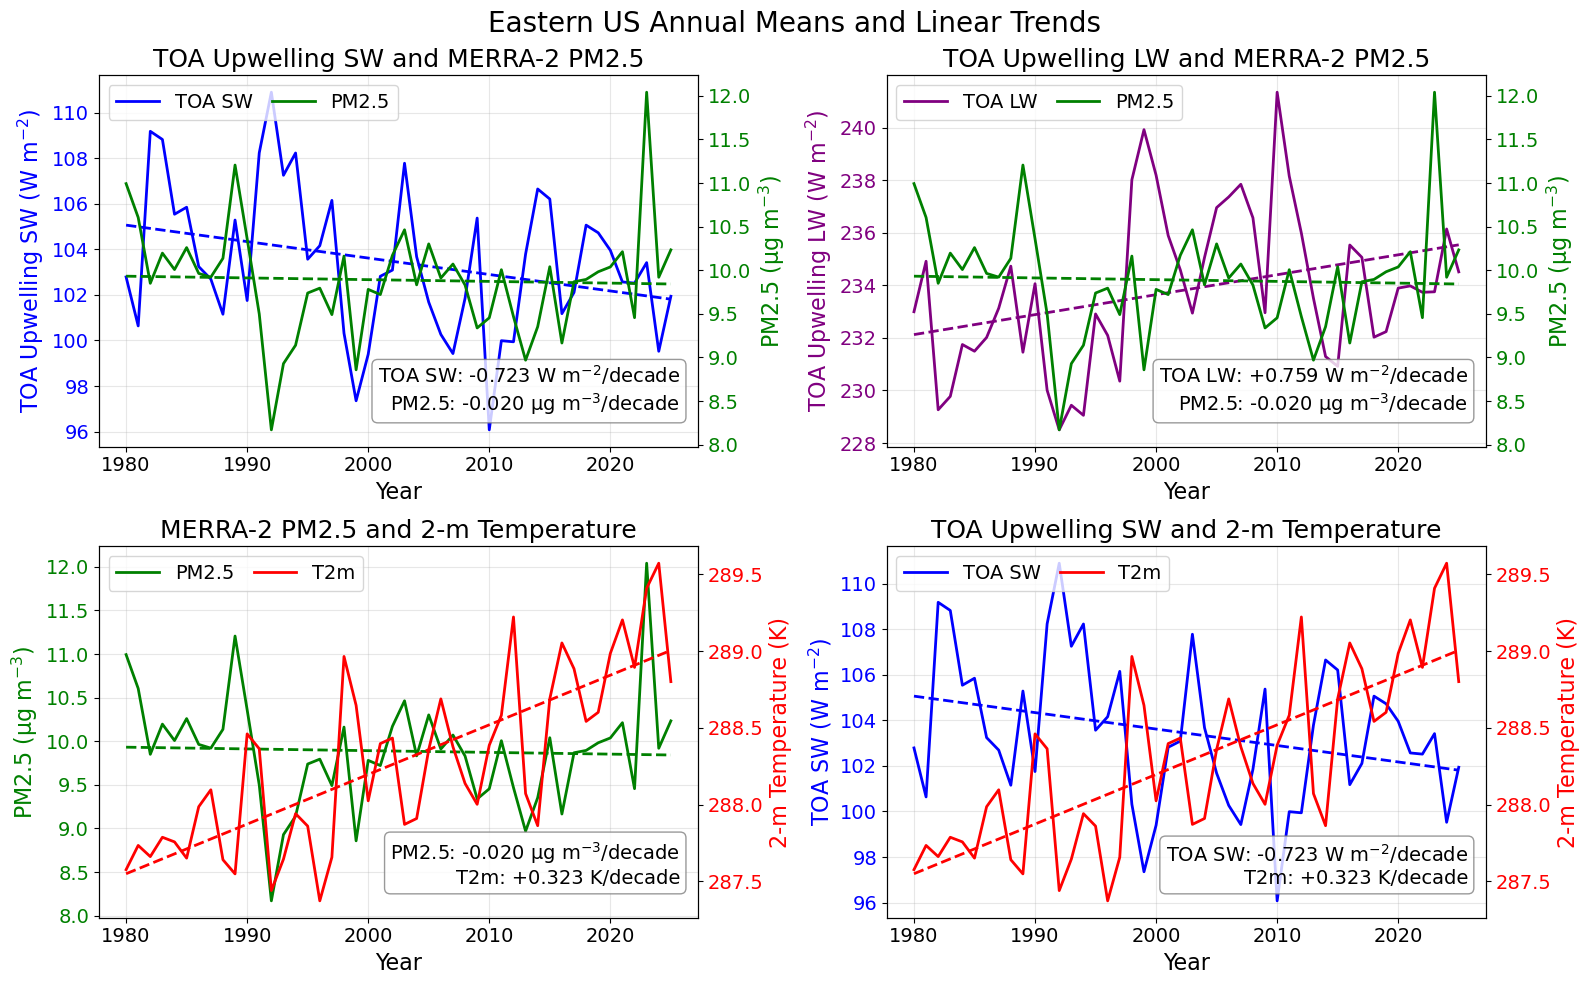

In [7]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# file paths
flux_file = "/scratch/sjacker2/project_data/merra2_rad_downloads/merra2_eastern_us_toa_upwelling_lw_sw_combined.nc"
pm25_file = "/scratch/sjacker2/project_data/merra2_pm25_t2m_eastern_us_monthly_means_DRY.nc"

# open datasets
ds_flux = xr.open_dataset(flux_file)
ds_pm = xr.open_dataset(pm25_file)

# check it's only 1980–2025
ds_flux = ds_flux.sel(time=slice("1980-01-01", "2025-12-31"))
ds_pm = ds_pm.sel(time=slice("1980-01-01", "2025-12-31"))
print(ds_flux)
print(ds_pm)

# fluxes aren't regional means yet so area-weight them
weights = np.cos(np.deg2rad(ds_flux["lat"]))
weights.name = "weights"

toa_sw_ts = ds_flux["TOA_SW_UP"].weighted(weights).mean(dim=("lat", "lon"))
toa_lw_ts = ds_flux["TOA_LW_UP"].weighted(weights).mean(dim=("lat", "lon"))

# already area-weighted by process_aer_slv.py
pm25_ts = ds_pm["PM25_mean"]
t2m_ts = ds_pm["T2M_mean"]

# compute annual means so seasonal variation doesn't get in the way
toa_sw_annual = toa_sw_ts.groupby("time.year").mean()
toa_lw_annual = toa_lw_ts.groupby("time.year").mean()
pm25_annual = pm25_ts.groupby("time.year").mean()
t2m_annual = t2m_ts.groupby("time.year").mean()

years = toa_sw_annual["year"].values.astype(float)

# fit linear trends
toa_sw_coeffs = np.polyfit(years, toa_sw_annual.values, 1)
toa_lw_coeffs = np.polyfit(years, toa_lw_annual.values, 1)
pm25_coeffs = np.polyfit(years, pm25_annual.values, 1)
t2m_coeffs = np.polyfit(years, t2m_annual.values, 1)

toa_sw_trendline = np.polyval(toa_sw_coeffs, years)
toa_lw_trendline = np.polyval(toa_lw_coeffs, years)
pm25_trendline = np.polyval(pm25_coeffs, years)
t2m_trendline = np.polyval(t2m_coeffs, years)

# trend per decade
toa_sw_trend_decade = toa_sw_coeffs[0] * 10
toa_lw_trend_decade = toa_lw_coeffs[0] * 10
pm25_trend_decade = pm25_coeffs[0] * 10
t2m_trend_decade = t2m_coeffs[0] * 10

# print trends
print("Annual-mean trends")
print("------------------")
print(f"TOA Upwelling SW:       {toa_sw_coeffs[0]:.4f} W m^-2/year")
print(f"TOA Upwelling SW:       {toa_sw_trend_decade:.4f} W m^-2/decade")
print()
print(f"TOA Upwelling LW:       {toa_lw_coeffs[0]:.4f} W m^-2/year")
print(f"TOA Upwelling LW:       {toa_lw_trend_decade:.4f} W m^-2/decade")
print()
print(f"PM2.5:        {pm25_coeffs[0]:.4f} µg m^-3/year")
print(f"PM2.5:        {pm25_trend_decade:.4f} µg m^-3/decade")
print()
print(f"T2M:          {t2m_coeffs[0]:.4f} K/year")
print(f"T2M:          {t2m_trend_decade:.4f} K/decade")


# function to plot each panel
def make_dual_panel(
    ax,
    years,
    left_data,
    left_trend,
    right_data,
    right_trend,
    left_axis_label,
    right_axis_label,
    left_legend_label,
    right_legend_label,
    left_color,
    right_color,
    title,
    left_trend_decade,
    right_trend_decade,
    left_trend_units,
    right_trend_units
):
    # left axis
    l1 = ax.plot(
        years,
        left_data,
        color=left_color,
        linewidth=2,
        label=left_legend_label
    )
    l2 = ax.plot(
        years,
        left_trend,
        color=left_color,
        linestyle="--",
        linewidth=2
    )

    ax.set_xlabel("Year", fontsize=16)
    ax.set_ylabel(left_axis_label, fontsize=16, color=left_color)
    ax.tick_params(axis="y", labelcolor=left_color, labelsize=14)
    ax.tick_params(axis="x", labelsize=14)
    ax.grid(True, alpha=0.3)

    # right axis
    axr = ax.twinx()
    l3 = axr.plot(
        years,
        right_data,
        color=right_color,
        linewidth=2,
        label=right_legend_label
    )
    l4 = axr.plot(
        years,
        right_trend,
        color=right_color,
        linestyle="--",
        linewidth=2
    )

    axr.set_ylabel(right_axis_label, fontsize=16, color=right_color)
    axr.tick_params(axis="y", labelcolor=right_color, labelsize=14)

    # combined legend
    lines = l1 + l2 + l3 + l4
    labels = [line.get_label() for line in lines]

    ax.legend(
        lines,
        labels,
        loc="upper left",
        frameon=True,
        fontsize=14,
        ncol=2,
        columnspacing=1.0,
        handlelength=2.2
    )

    # trend text box
    trend_text = (
        f"{left_legend_label}: {left_trend_decade:+.3f} {left_trend_units}/decade\n"
        f"{right_legend_label}: {right_trend_decade:+.3f} {right_trend_units}/decade"
    )

    ax.text(
        0.97,
        0.08,
        trend_text,
        transform=ax.transAxes,
        fontsize=14,
        verticalalignment="bottom",
        horizontalalignment="right",
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.8,
            edgecolor="gray"
        )
    )

    ax.set_title(title, fontsize=18)


# create 4-panel figure
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Panel 1 is TOA SW + PM2.5
make_dual_panel(
    axes[0, 0], years,
    toa_sw_annual, toa_sw_trendline,
    pm25_annual, pm25_trendline,
    "TOA Upwelling SW (W m$^{-2}$)", "PM2.5 (µg m$^{-3}$)",
    "TOA SW", "PM2.5",
    "blue", "green",
    "TOA Upwelling SW and MERRA-2 PM2.5",
    toa_sw_trend_decade,
    pm25_trend_decade,
    "W m$^{-2}$",
    "µg m$^{-3}$"
)

# Panel 2 is TOA LW + PM2.5
make_dual_panel(
    axes[0, 1], years,
    toa_lw_annual, toa_lw_trendline,
    pm25_annual, pm25_trendline,
    "TOA Upwelling LW (W m$^{-2}$)", "PM2.5 (µg m$^{-3}$)",
    "TOA LW", "PM2.5",
    "purple", "green",
    "TOA Upwelling LW and MERRA-2 PM2.5",
    toa_lw_trend_decade,
    pm25_trend_decade,
    "W m$^{-2}$",
    "µg m$^{-3}$"
)

# Panel 3 is PM2.5 + 2-m temperature
make_dual_panel(
    axes[1, 0], years,
    pm25_annual, pm25_trendline,
    t2m_annual, t2m_trendline,
    "PM2.5 (µg m$^{-3}$)", "2-m Temperature (K)",
    "PM2.5", "T2m",
    "green", "red",
    "MERRA-2 PM2.5 and 2-m Temperature",
    pm25_trend_decade,
    t2m_trend_decade,
    "µg m$^{-3}$",
    "K"
)

# Panel 4 is TOA SW + 2-m temperature
make_dual_panel(
    axes[1, 1], years,
    toa_sw_annual, toa_sw_trendline,
    t2m_annual, t2m_trendline,
    "TOA SW (W m$^{-2}$)", "2-m Temperature (K)",
    "TOA SW", "T2m",
    "blue", "red",
    "TOA Upwelling SW and 2-m Temperature",
    toa_sw_trend_decade,
    t2m_trend_decade,
    "W m$^{-2}$",
    "K"
)

plt.suptitle("Eastern US Annual Means and Linear Trends", fontsize=20)
plt.tight_layout()
plt.show()

<xarray.Dataset> Size: 9MB
Dimensions:    (time: 552, lat: 51, lon: 41)
Coordinates:
  * time       (time) datetime64[ns] 4kB 1980-01-01T00:30:00 ... 2025-12-01T0...
  * lat        (lat) float64 408B 25.0 25.5 26.0 26.5 ... 48.5 49.0 49.5 50.0
  * lon        (lon) float64 328B -90.0 -89.38 -88.75 ... -66.25 -65.62 -65.0
Data variables:
    TOA_LW_UP  (time, lat, lon) float32 5MB ...
    TOA_SW_UP  (time, lat, lon) float32 5MB ...
Attributes:
    title:             MERRA-2 Eastern US TOA upwelling longwave and shortwav...
    source_directory:  /scratch/sjacker2/project_data/merra2_rad_downloads
    note:              TOA_LW_UP = LWTUP; TOA_SW_UP = SWTDN - SWTNT. Data alr...
<xarray.Dataset> Size: 11kB
Dimensions:    (time: 552)
Coordinates:
  * time       (time) datetime64[ns] 4kB 1980-01-01T00:30:00 ... 2025-12-01T0...
Data variables:
    PM25_mean  (time) float64 4kB ...
    T2M_mean   (time) float32 2kB ...
Attributes:
    title:         Monthly eastern US means of total PM2.5 and 2

/tmp/ipykernel_940990/2113104192.py:137: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  ax.legend(


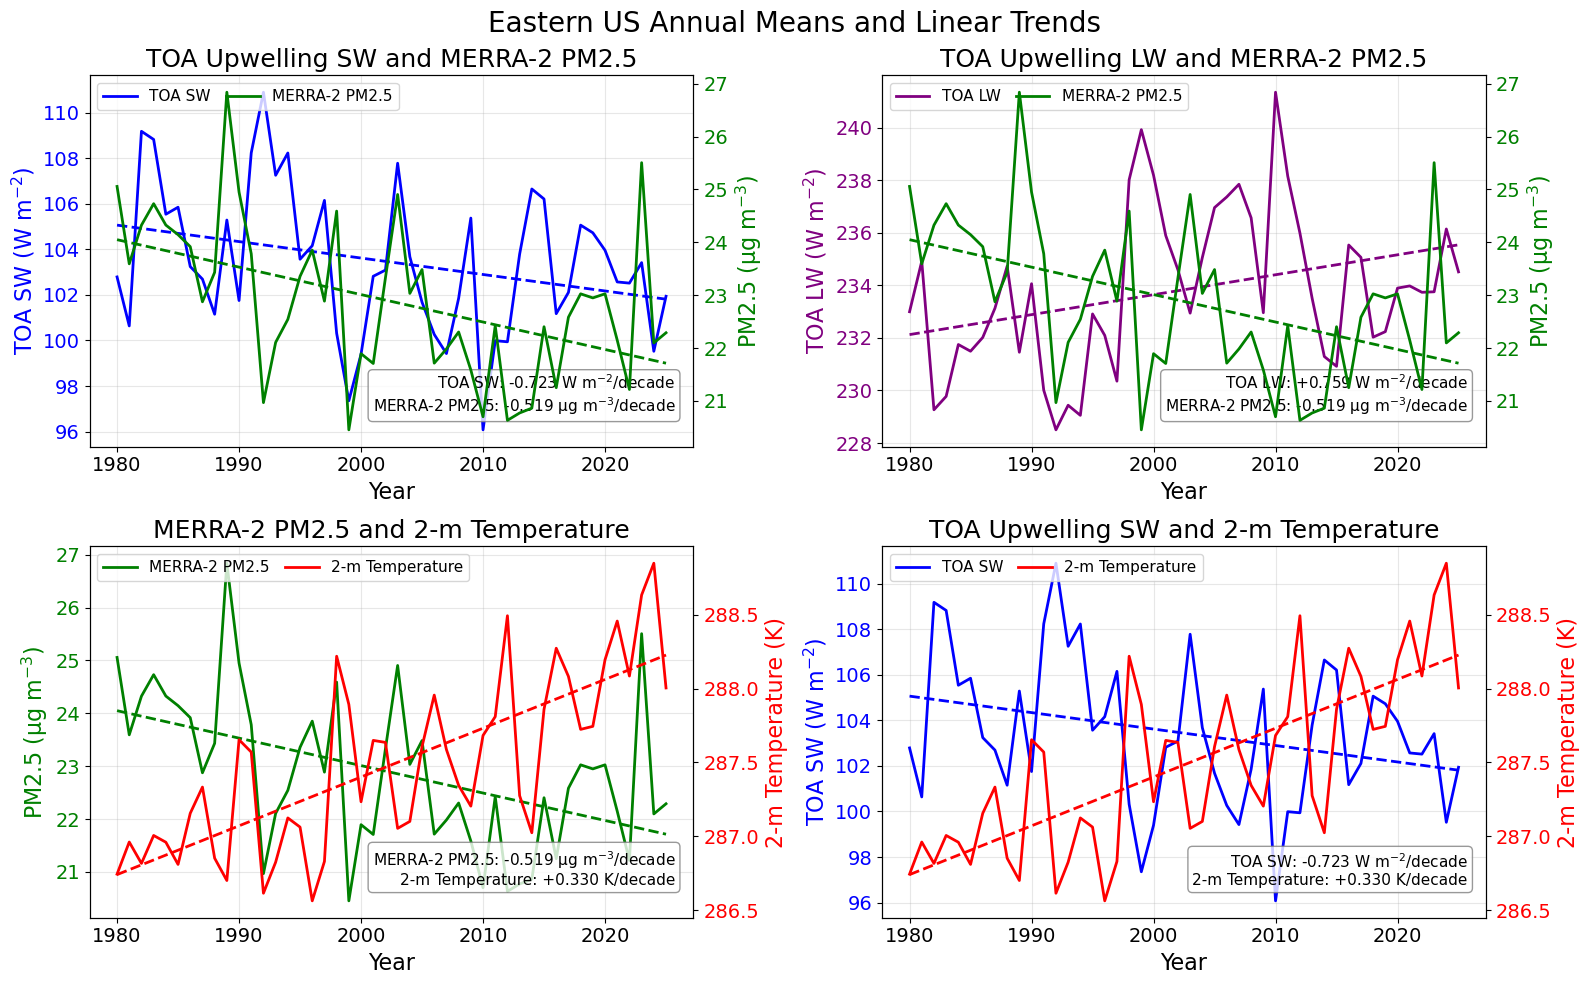

In [3]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# file paths
flux_file = "/scratch/sjacker2/project_data//merra2_rad_downloads/merra2_eastern_us_toa_upwelling_lw_sw_combined.nc"
pm25_file = "/scratch/sjacker2/project_data/merra2_pm25_t2m_eastern_us_monthly_means.nc"

# open datasets
ds_flux = xr.open_dataset(flux_file)
ds_pm = xr.open_dataset(pm25_file)

# check it's only 1980–2025
ds_flux = ds_flux.sel(time=slice("1980-01-01", "2025-12-31"))
ds_pm = ds_pm.sel(time=slice("1980-01-01", "2025-12-31"))
print(ds_flux)
print(ds_pm)

# fluxes aren't regional means yet so area-weight them
weights = np.cos(np.deg2rad(ds_flux["lat"]))
weights.name = "weights"

toa_sw_ts = ds_flux["TOA_SW_UP"].weighted(weights).mean(dim=("lat", "lon"))
toa_lw_ts = ds_flux["TOA_LW_UP"].weighted(weights).mean(dim=("lat", "lon"))

# already area-weighted by process_aer_slv.py
pm25_ts = ds_pm["PM25_mean"]
t2m_ts = ds_pm["T2M_mean"]

# compute annual means so seasonal variation doesn't get in the way
toa_sw_annual = toa_sw_ts.groupby("time.year").mean()
toa_lw_annual = toa_lw_ts.groupby("time.year").mean()
pm25_annual = pm25_ts.groupby("time.year").mean()
t2m_annual = t2m_ts.groupby("time.year").mean()

years = toa_sw_annual["year"].values.astype(float)

# fit linear trends
toa_sw_coeffs = np.polyfit(years, toa_sw_annual.values, 1)
toa_lw_coeffs = np.polyfit(years, toa_lw_annual.values, 1)
pm25_coeffs = np.polyfit(years, pm25_annual.values, 1)
t2m_coeffs = np.polyfit(years, t2m_annual.values, 1)

toa_sw_trendline = np.polyval(toa_sw_coeffs, years)
toa_lw_trendline = np.polyval(toa_lw_coeffs, years)
pm25_trendline = np.polyval(pm25_coeffs, years)
t2m_trendline = np.polyval(t2m_coeffs, years)

# trend per decade
toa_sw_trend_decade = toa_sw_coeffs[0] * 10
toa_lw_trend_decade = toa_lw_coeffs[0] * 10
pm25_trend_decade = pm25_coeffs[0] * 10
t2m_trend_decade = t2m_coeffs[0] * 10

# print trends
print("Annual-mean trends")
print("------------------")
print(f"TOA SW:       {toa_sw_coeffs[0]:.4f} W m^-2/year")
print(f"TOA SW:       {toa_sw_trend_decade:.4f} W m^-2/decade")
print()
print(f"TOA LW:       {toa_lw_coeffs[0]:.4f} W m^-2/year")
print(f"TOA LW:       {toa_lw_trend_decade:.4f} W m^-2/decade")
print()
print(f"PM2.5:        {pm25_coeffs[0]:.4f} µg m^-3/year")
print(f"PM2.5:        {pm25_trend_decade:.4f} µg m^-3/decade")
print()
print(f"T2M:          {t2m_coeffs[0]:.4f} K/year")
print(f"T2M:          {t2m_trend_decade:.4f} K/decade")


# function to plot each panel
def make_dual_panel(
    ax,
    years,
    left_data,
    left_trend,
    right_data,
    right_trend,
    left_axis_label,
    right_axis_label,
    left_legend_label,
    right_legend_label,
    left_color,
    right_color,
    title,
    left_trend_decade,
    right_trend_decade,
    left_trend_units,
    right_trend_units
):
    # left axis
    l1 = ax.plot(
        years,
        left_data,
        color=left_color,
        linewidth=2,
        label=left_legend_label
    )
    l2 = ax.plot(
        years,
        left_trend,
        color=left_color,
        linestyle="--",
        linewidth=2
    )

    ax.set_xlabel("Year", fontsize=16)
    ax.set_ylabel(left_axis_label, fontsize=16, color=left_color)
    ax.tick_params(axis="y", labelcolor=left_color, labelsize=14)
    ax.tick_params(axis="x", labelsize=14)
    ax.grid(True, alpha=0.3)

    # right axis
    axr = ax.twinx()
    l3 = axr.plot(
        years,
        right_data,
        color=right_color,
        linewidth=2,
        label=right_legend_label
    )
    l4 = axr.plot(
        years,
        right_trend,
        color=right_color,
        linestyle="--",
        linewidth=2
    )

    axr.set_ylabel(right_axis_label, fontsize=16, color=right_color)
    axr.tick_params(axis="y", labelcolor=right_color, labelsize=14)

    # combined legend
    lines = l1 + l2 + l3 + l4
    labels = [line.get_label() for line in lines]

    ax.legend(
        lines,
        labels,
        loc="upper left",
        frameon=True,
        fontsize=11,
        ncol=2,
        columnspacing=1.0,
        handlelength=2.2
    )

    # trend text box
    trend_text = (
        f"{left_legend_label}: {left_trend_decade:+.3f} {left_trend_units}/decade\n"
        f"{right_legend_label}: {right_trend_decade:+.3f} {right_trend_units}/decade"
    )

    ax.text(
        0.97,
        0.08,
        trend_text,
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment="bottom",
        horizontalalignment="right",
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.8,
            edgecolor="gray"
        )
    )

    ax.set_title(title, fontsize=18)


# create 4-panel figure
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Panel 1 is TOA SW + PM2.5
make_dual_panel(
    axes[0, 0], years,
    toa_sw_annual, toa_sw_trendline,
    pm25_annual, pm25_trendline,
    "TOA SW (W m$^{-2}$)", "PM2.5 (µg m$^{-3}$)",
    "TOA SW", "MERRA-2 PM2.5",
    "blue", "green",
    "TOA Upwelling SW and MERRA-2 PM2.5",
    toa_sw_trend_decade,
    pm25_trend_decade,
    "W m$^{-2}$",
    "µg m$^{-3}$"
)

# Panel 2 is TOA LW + PM2.5
make_dual_panel(
    axes[0, 1], years,
    toa_lw_annual, toa_lw_trendline,
    pm25_annual, pm25_trendline,
    "TOA LW (W m$^{-2}$)", "PM2.5 (µg m$^{-3}$)",
    "TOA LW", "MERRA-2 PM2.5",
    "purple", "green",
    "TOA Upwelling LW and MERRA-2 PM2.5",
    toa_lw_trend_decade,
    pm25_trend_decade,
    "W m$^{-2}$",
    "µg m$^{-3}$"
)

# Panel 3 is PM2.5 + 2-m temperature
make_dual_panel(
    axes[1, 0], years,
    pm25_annual, pm25_trendline,
    t2m_annual, t2m_trendline,
    "PM2.5 (µg m$^{-3}$)", "2-m Temperature (K)",
    "MERRA-2 PM2.5", "2-m Temperature",
    "green", "red",
    "MERRA-2 PM2.5 and 2-m Temperature",
    pm25_trend_decade,
    t2m_trend_decade,
    "µg m$^{-3}$",
    "K"
)

# Panel 4 is TOA SW + 2-m temperature
make_dual_panel(
    axes[1, 1], years,
    toa_sw_annual, toa_sw_trendline,
    t2m_annual, t2m_trendline,
    "TOA SW (W m$^{-2}$)", "2-m Temperature (K)",
    "TOA SW", "2-m Temperature",
    "blue", "red",
    "TOA Upwelling SW and 2-m Temperature",
    toa_sw_trend_decade,
    t2m_trend_decade,
    "W m$^{-2}$",
    "K"
)

plt.suptitle("Eastern US Annual Means and Linear Trends", fontsize=20)
plt.tight_layout()
plt.show()

PM2.5 trend: -0.0020 µg m^-3/year
PM2.5 trend: -0.0199 µg m^-3/decade

T2M trend:   0.0323 K/year
T2M trend:   0.3234 K/decade


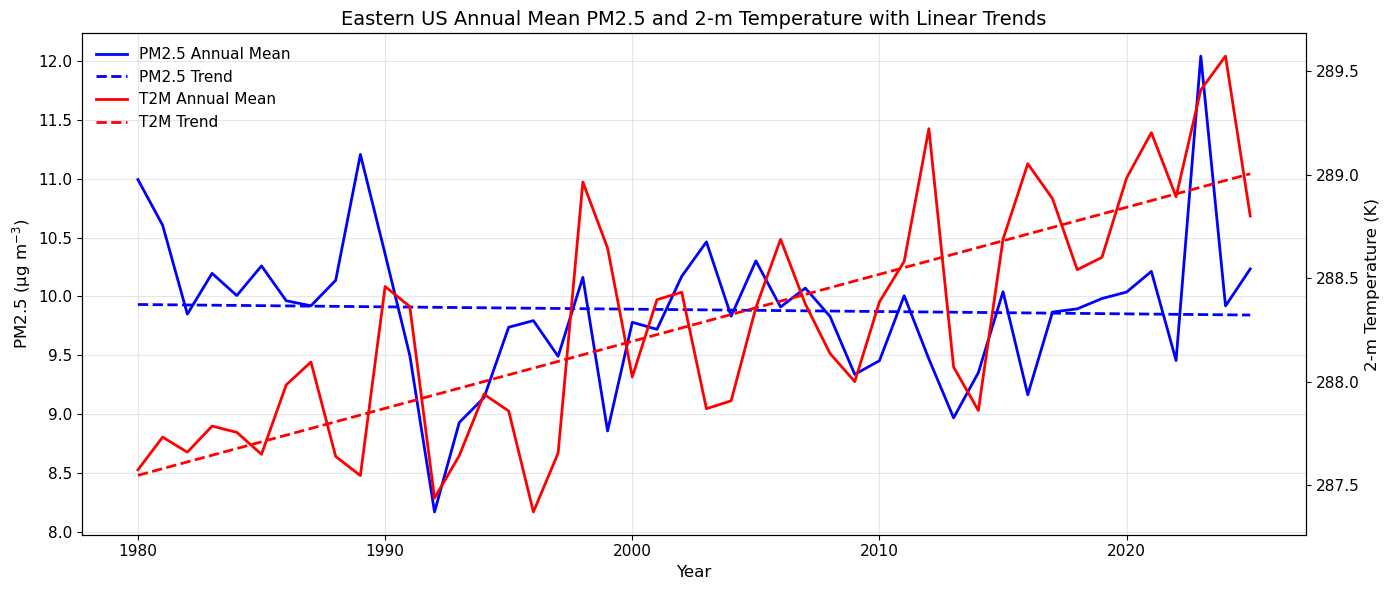

In [5]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# -----------------------------
# File path
# -----------------------------
nc_file = "/scratch/sjacker2/project_data/merra2_pm25_t2m_eastern_us_monthly_means_DRY.nc"

# -----------------------------
# Open dataset
# -----------------------------
ds = xr.open_dataset(nc_file)

# -----------------------------
# Extract variables
# -----------------------------
pm25_ts = ds["PM25_mean"]
t2m_ts = ds["T2M_mean"]

# -----------------------------
# Compute annual means
# -----------------------------
pm25_annual = pm25_ts.groupby("time.year").mean()
t2m_annual = t2m_ts.groupby("time.year").mean()

years = pm25_annual["year"].values.astype(float)

# -----------------------------
# Fit linear trends to annual means
# -----------------------------
pm25_coeffs = np.polyfit(years, pm25_annual.values, 1)
t2m_coeffs = np.polyfit(years, t2m_annual.values, 1)

pm25_trendline = np.polyval(pm25_coeffs, years)
t2m_trendline = np.polyval(t2m_coeffs, years)

# -----------------------------
# Print trends
# -----------------------------
pm25_trend_per_year = pm25_coeffs[0]
t2m_trend_per_year = t2m_coeffs[0]

pm25_trend_decade = pm25_trend_per_year * 10
t2m_trend_decade = t2m_trend_per_year * 10

print(f"PM2.5 trend: {pm25_trend_per_year:.4f} µg m^-3/year")
print(f"PM2.5 trend: {pm25_trend_decade:.4f} µg m^-3/decade")
print()
print(f"T2M trend:   {t2m_trend_per_year:.4f} K/year")
print(f"T2M trend:   {t2m_trend_decade:.4f} K/decade")

# -----------------------------
# Make figure
# -----------------------------
fig, ax1 = plt.subplots(figsize=(14, 6))

# Left y-axis: annual PM2.5
l1 = ax1.plot(years, pm25_annual, label="PM2.5 Annual Mean", linewidth=2, color="blue")
l2 = ax1.plot(years, pm25_trendline, linestyle="--", linewidth=2, label="PM2.5 Trend", color="blue")
ax1.set_xlabel("Year", fontsize=12)
ax1.set_ylabel("PM2.5 (µg m$^{-3}$)", fontsize=12)
ax1.tick_params(axis="y", labelsize=11)
ax1.tick_params(axis="x", labelsize=11)
ax1.grid(True, alpha=0.3)

# Right y-axis: annual T2M
ax2 = ax1.twinx()
l3 = ax2.plot(years, t2m_annual, label="T2M Annual Mean", linewidth=2, color="red")
l4 = ax2.plot(years, t2m_trendline, linestyle="--", linewidth=2, label="T2M Trend", color="red")
ax2.set_ylabel("2-m Temperature (K)", fontsize=12)
ax2.tick_params(axis="y", labelsize=11)

# Combined legend
lines = l1 + l2 + l3 + l4
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper left", frameon=False, fontsize=11)

plt.title("Eastern US Annual Mean PM2.5 and 2-m Temperature with Linear Trends", fontsize=14)
plt.tight_layout()
plt.show()